# Carga de Datos XRF y Evaluación de Ruido
Este cuaderno carga imágenes TIFF multicanal elementales, evalúa el histograma de intensidad total $T(p)$
y genera la máscara de píxeles válidos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xrf.io.xrf_loader import Xrf_Loader
from xrf.config import Xrf_Preprocessing_Config

In [2]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data

DATA_DIR = PROJECT_DIR / "data"/ "xrf"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
config = Xrf_Preprocessing_Config(Noise_Threshold=5.0)

In [ ]:

file_paths = [
    RAW_DATA_DIR / "BX2080black_ink_As_Ka_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Cu_Ka_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Au_La_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Hg_La_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Pb_La_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Zn_Ka_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Ca_Ka_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_Fe_Ka_raw.tiff",
    RAW_DATA_DIR / "BX2080black_ink_K_Ka_raw.tiff"
]

# Load Stack and mask compute   
stack = Xrf_Loader.Load_Element_Stack(file_paths, Dtype=config.Compute_Dtype)
mask, valid_pixels = Xrf_Loader.Compute_Intensity_Mask(stack, config.Noise_Threshold)

print(f"Stack Loaded: {stack.shape}")
print(f"Valid Pixels: {valid_pixels.shape[0]} de {mask.size}")

# Artifacts exports
np.save(PROCESSED_DATA_DIR / "page_001_mask.npy", mask)
np.save(PROCESSED_DATA_DIR / "page_001_valid_pixels.npy", valid_pixels)
print(f"Export data to {PROCESSED_DATA_DIR}")

Stack cargado: (1492, 2284, 9)
Píxeles válidos: 3407728 de 3407728
Datos exportados exitosamente a c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\xrf\output\processed


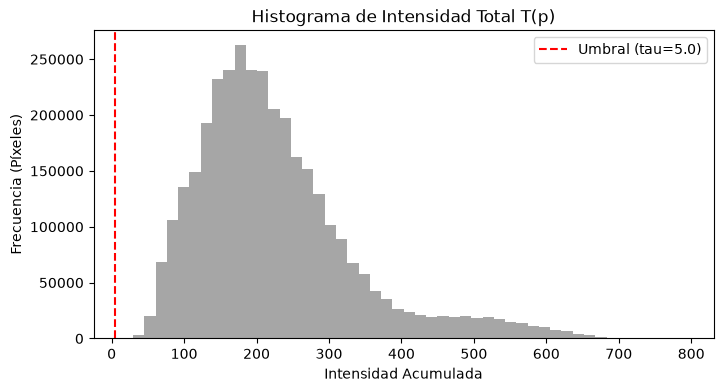

Píxeles válidos retenidos: 3407728 (100.0%)


In [ ]:
# Total intensities T(p) computing and mask generation
total_intensity = np.sum(stack, axis=-1)

plt.figure(figsize=(8, 4))
plt.hist(total_intensity.ravel(), bins=50, color="gray", alpha=0.7)
plt.axvline(
    x=config.Noise_Threshold,
    color="red",
    linestyle="--",
    label=f"Threshold (tau={config.Noise_Threshold})",
)
plt.title("Total intensities T(p) histogram ")
plt.xlabel("Acumulated Intensity")
plt.ylabel("Frequency (Pixels)")
plt.legend()
plt.show()

mask, valid_pixels = Xrf_Loader.Compute_Intensity_Mask(stack, config.Noise_Threshold)
print(
    f"Valid pixels retained: {valid_pixels.shape[0]} ({valid_pixels.shape[0] / total_intensity.size:.1%})"
)

In [ ]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

np.save(PROCESSED_DATA_DIR / "page_001_mask.npy", mask)
np.save(PROCESSED_DATA_DIR / "page_001_valid_pixels.npy", valid_pixels)

print(f"Export data to {PROCESSED_DATA_DIR}")

Datos exportados a c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\xrf\output\processed
